<a href="https://colab.research.google.com/github/dhruvlikhare-coder/Dijkstra-algorithm/blob/main/linear%20regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# preaparing the enviroment
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,5)

# applying the haversine distance formula
def harvesian_distance(df):
  r = 3958.8
  phi_1 = np.radians(df['pickup_latitude'])
  phi_2 = np.radians(df['dropoff_latitude'])
  delta_phi = np.radians(phi_2 - phi_1)
  delta_lambda = np.radians(df['dropoff_longitude'] - df['pickup_longitude'])
  a = np.sin(delta_phi / 2)**2 + np.cos(phi_1) * np.cos(phi_2)* np.sin(delta_lambda / 2)**2
  c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
  df['distance_miles'] = r * c
  return df

# loading the data
df = pd.read_csv('/train.csv')

# apply haversian distance calculation
df = harvesian_distance(df)

# Adjusting filters for a more realistic NYC dataset
# NYC Latitude is roughly 40.7. Filtering for 40.5 to 40.9.
df = df[(df['pickup_latitude'] >= 40.5) & (df['pickup_latitude'] <= 40.9)]
# Filtering for typical trips (e.g., up to 30 miles) and removing negative/zero fares
df = df[(df['distance_miles'] > 0) & (df['distance_miles'] <= 30)]
df = df[(df['fare_amount'] > 0) & (df['fare_amount'] < 200)]


In [ ]:
df = pd.read_csv('/train.csv')
df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1


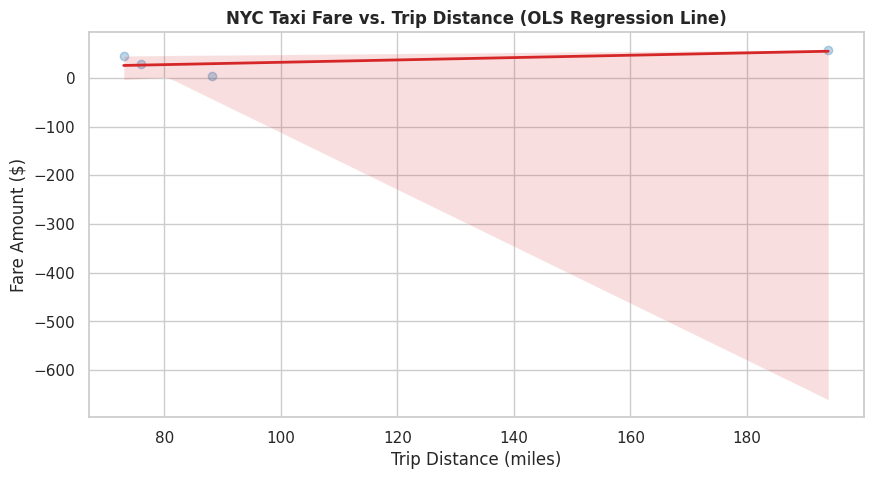

In [ ]:
# ploting the data
plt.figure(figsize=(10,5))

# Calculate sample size safely based on population size
sample_size = min(len(df), 2000)

sns.regplot(
    data=df.sample(n=sample_size, random_state=42), # Subsample for fast plotting
    x='distance_miles',
    y='fare_amount',
    scatter_kws={'alpha': 0.3, 'color': '#1f77b4'},
    line_kws={'color': '#d62728', 'linewidth': 2}
)
plt.title('NYC Taxi Fare vs. Trip Distance (OLS Regression Line)', fontsize = 12, fontweight = 'bold')
plt.xlabel('Trip Distance (miles)', fontsize = 12)
plt.ylabel('Fare Amount ($)', fontsize = 12)
plt.show()

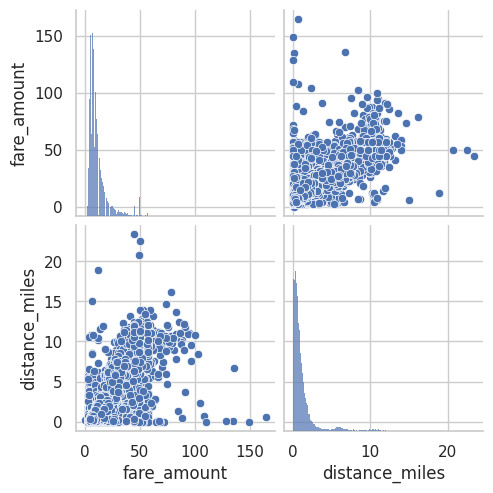

In [ ]:
corr_cols = ['fare_amount', 'distance_miles']
sns.pairplot(df[corr_cols])
plt.show()

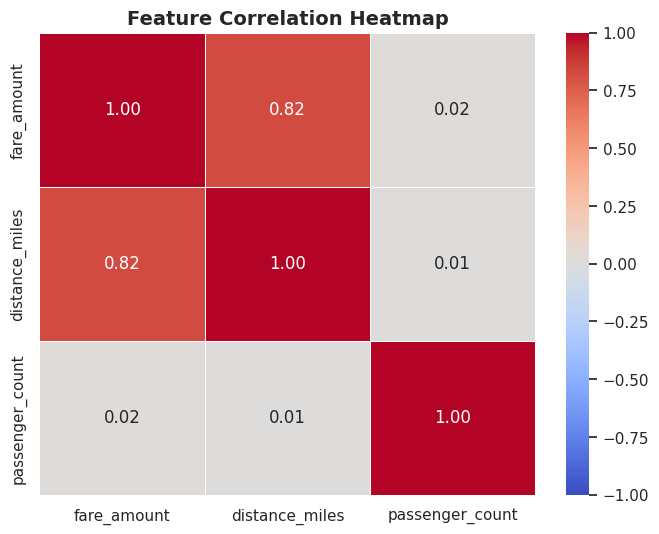

In [ ]:
# Select key numerical columns
corr_cols = ['fare_amount', 'distance_miles', 'passenger_count']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

In [ ]:
from sklearn.metrics import r2_score

x = df[['distance_miles', 'passenger_count']]
y = df['fare_amount']

# Correct unpacking order: X_train, X_test, y_train, y_test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# train linear regression
model = LinearRegression()
model.fit(x_train, y_train)

# Generate predictions for evaluation
y_pred = model.predict(x_test)

print(f"Base Fare (Intercept): ${model.intercept_:.2f}")
print(f"Cost per Mile: ${model.coef_[0]:.2f}")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

Base Fare (Intercept): $6.02
Cost per Mile: $4.36
R² Score: 0.6944
RMSE: $5.15


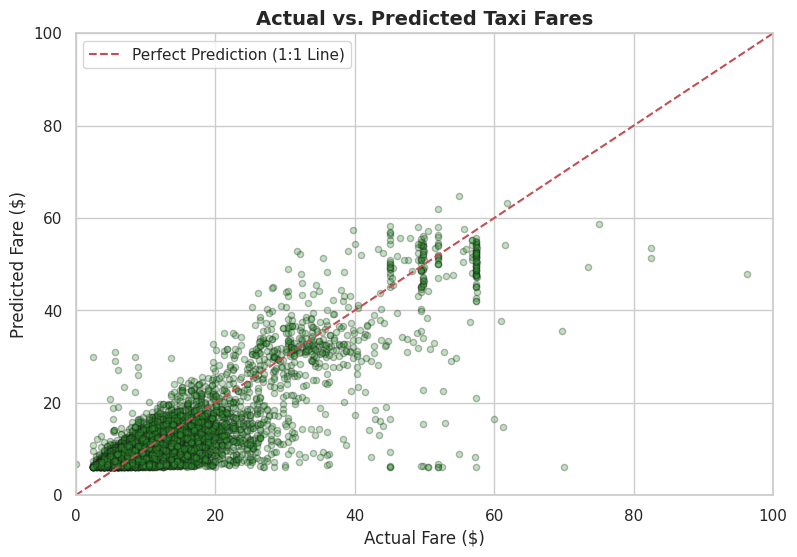

In [ ]:
plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='#2ca02c', edgecolor='k', s=20)
plt.plot([y_test.min(), 100], [y_test.min(), 100], 'r--', label='Perfect Prediction (1:1 Line)')

plt.title('Actual vs. Predicted Taxi Fares', fontsize=14, fontweight='bold')
plt.xlabel('Actual Fare ($)', fontsize=12)
plt.ylabel('Predicted Fare ($)', fontsize=12)
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend()
plt.show()